In [12]:
import sys
sys.path.append('/blue/adamginsburg/t.yoo/SPICY_ALMAIMF')
import imp, table_loading
imp.reload(table_loading)
from table_loading import fit_a_source, geometries
from astropy.table import Table
from plot_fit import plot_fit, datafunction
import numpy as np
from astropy import constants
from astropy import units as u
from astropy.modeling import models, fitting



In [13]:
from photutils.aperture import SkyCircularAperture
from photutils.aperture import aperture_photometry
from photutils.aperture import SkyCircularAnnulus
from photutils.aperture import ApertureStats
from astropy.wcs import WCS
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table
#from filtering import get_filtername, get_fwhm
import plot_fit
from astroquery.svo_fps import SvoFps
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
import plot_fit
imp.reload(plot_fit)
from plot_fit import plot_fit, datafunction
from scipy.ndimage import binary_dilation
from matplotlib.lines import Line2D



catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new.fits')
nmatch = catalog['nmatch_bands']
catalog = catalog[nmatch>3]

image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}


f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))

def get_mag(catalog, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err

f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')

f162 = f162m_mag[0].to_value(u.mag)
f210 = f210m_mag[0].to_value(u.mag)
f360 = f360m_mag[0].to_value(u.mag)
f480 = f480m_mag[0].to_value(u.mag)

num_sources = len(catalog)

from dust_extinction.averages import RL85_MWGC, CT06_MWGC
from dust_extinction.parameter_averages import CCM89
import astropy.constants as const

ext = CT06_MWLoc()

mags = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
   # 'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    #'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}


def get_av(color, mag, ext=CT06_MWLoc(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=None):
    # Get the slope and intercept of the isochrone line
    m_iso, b_iso = isochrone_line_params
    print('color1:', color1, 'mag1:', mag1)

    # Get the extinction vector components
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    print('w_color1_1:', w_color1_1, 'w_color1_2:', w_color1_2, 'w_mag1:', w_mag1)

    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)

    # get the contact to the isochrone line along the extinction vector
    # the extinction vector can be represented as a line with slope m_ext = e_mag1 / (e_color1_1 - e_color1_2) and passing through the point (color, mag)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color

    # find the intersection of the isochrone line and the extinction vector
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    # calculate A_V as the distance from (color, mag) to (x_int, y_int) along the extinction vector
    av = (mag - y_int) / ext(1/w_mag1)
    av[av < 0] = 0
    return av
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec_av0.pprint(max_width=-1, max_lines=-1)   
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]              
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
print(np.min(m_init), np.max(m_init))
print(np.min(mass_av0), np.max(mass_av0))
F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5
age_idx = logage_av0 == 6
idx_01msun = np.argmin(np.abs(mass_av0[age_idx]-0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx]-20))
isochrone_x_start = F162Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F162Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isocrhone_y_start = F162Mmag_av0[age_idx][idx_01msun]
isocrhone_y_end = F162Mmag_av0[age_idx][idx_20msun]
color_slope = (isocrhone_y_end - isocrhone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isocrhone_y_start - color_slope * isochrone_x_start
av_estimates = get_av(color=f162-f210, mag=f162, ext=CT06_MWLoc(), color1=('f162m', 'f210m'), mag1=('f162m',), isochrone_line_params=(color_slope, color_intercept))





7.525093724479512e-11 deg2
7.52790883669383e-11 deg2
7.52510476872822e-11 deg2
7.52514718037244e-11 deg2
3.053877779107583e-10 deg2
3.0536898714608487e-10 deg2
3.056563930691893e-10 deg2
3.0541063885182936e-10 deg2
3.054668262896466e-10 deg2
9.491459138193236e-10 deg2
9.491652259572426e-10 deg2
9.491458943030916e-10 deg2
9.491652069110604e-10 deg2
9.491651972183757e-10 deg2
7.524574264515582e-11 deg2
 col1    col2  col3      col4          col5       col6   col7   col8   col9  col10 col11 col12   col13  col14  col15  col16  col17  col18   col19   col20   col21   col22    col23     col24     col25   col26   col27   col28   col29   col30   col31   col32   col33   col34   col35   col36   col37   col38   col39   col40   col41   col42   col43   col44   col45   col46   col47   col48   col49   col50 
------ ------- ---- -------------- ------------ ------- ------ ------ ------ ----- ----- ------ ------- ------ ------ ------ ------ ----- --------- ----- --------- ------ --------- --------- -----

filt: f140m, flux_fit: 12.59690804117674, flux_err: 0.614489768240214
filt: f162m, flux_fit: 39.50379425069509, flux_err: 0.7736682174211169
filt: f182m, flux_fit: 90.54999242755868, flux_err: 0.8361677946353936
filt: f210m, flux_fit: 191.1219586499423, flux_err: 1.1806407590862262
filt: f335m, flux_fit: 203.78874264674508, flux_err: 2.4097922065624506
filt: f360m, flux_fit: 242.57656008028692, flux_err: 2.297348336722179
filt: f410m, flux_fit: 300.79311425312176, flux_err: 4.793390746643567
filt: f480m, flux_fit: 368.95366501506066, flux_err: 5.940548828502684
filt: f560w, flux_fit: --, flux_err: --
filt: f770w, flux_fit: --, flux_err: --
filt: f1000w, flux_fit: --, flux_err: --
filt: f1280w, flux_fit: --, flux_err: --
filt: f2100w, flux_fit: --, flux_err: --
wcss[filt].proj_plane_pixel_area(): 7.525093724479512e-11 deg2
catalog[idx][f"flux_err_{filt}"]: 0.614489768240214
fluxarr [0.00028876 0.00090587 0.00207566 0.00438107 0.01895774 0.02256464
 0.02798381 0.03433133]
['b3_id', 'b6_i

   Reading fluxes at 1.62 um
   Reading fluxes at 1.82 um
   Reading fluxes at 2.1 um
   Reading fluxes at 3.35 um
   Reading fluxes at 3.6 um
   Reading fluxes at 4.1 um
   Reading fluxes at 4.8 um
Moved array with size (720000, 8) to /tmp/tmp36rw9r3u/spubhmi.dat
 ------------------------------------------------------------
  => Model parameters
 ------------------------------------------------------------

   Models              :  spubsmi
   Log[d] stepping     :  0.02
   Number of distances :  2

 ------------------------------------------------------------
  => Reading in convolved fluxes
 ------------------------------------------------------------

Data shape=(360000, 2, 8).  use_memmap=True
   Reading fluxes at 1.4 um
   Reading fluxes at 1.62 um
   Reading fluxes at 1.82 um
   Reading fluxes at 2.1 um
   Reading fluxes at 3.35 um
   Reading fluxes at 3.6 um
   Reading fluxes at 4.1 um
   Reading fluxes at 4.8 um
Moved array with size (360000, 8) to /tmp/tmp79ydbrm0/spubsmi.dat

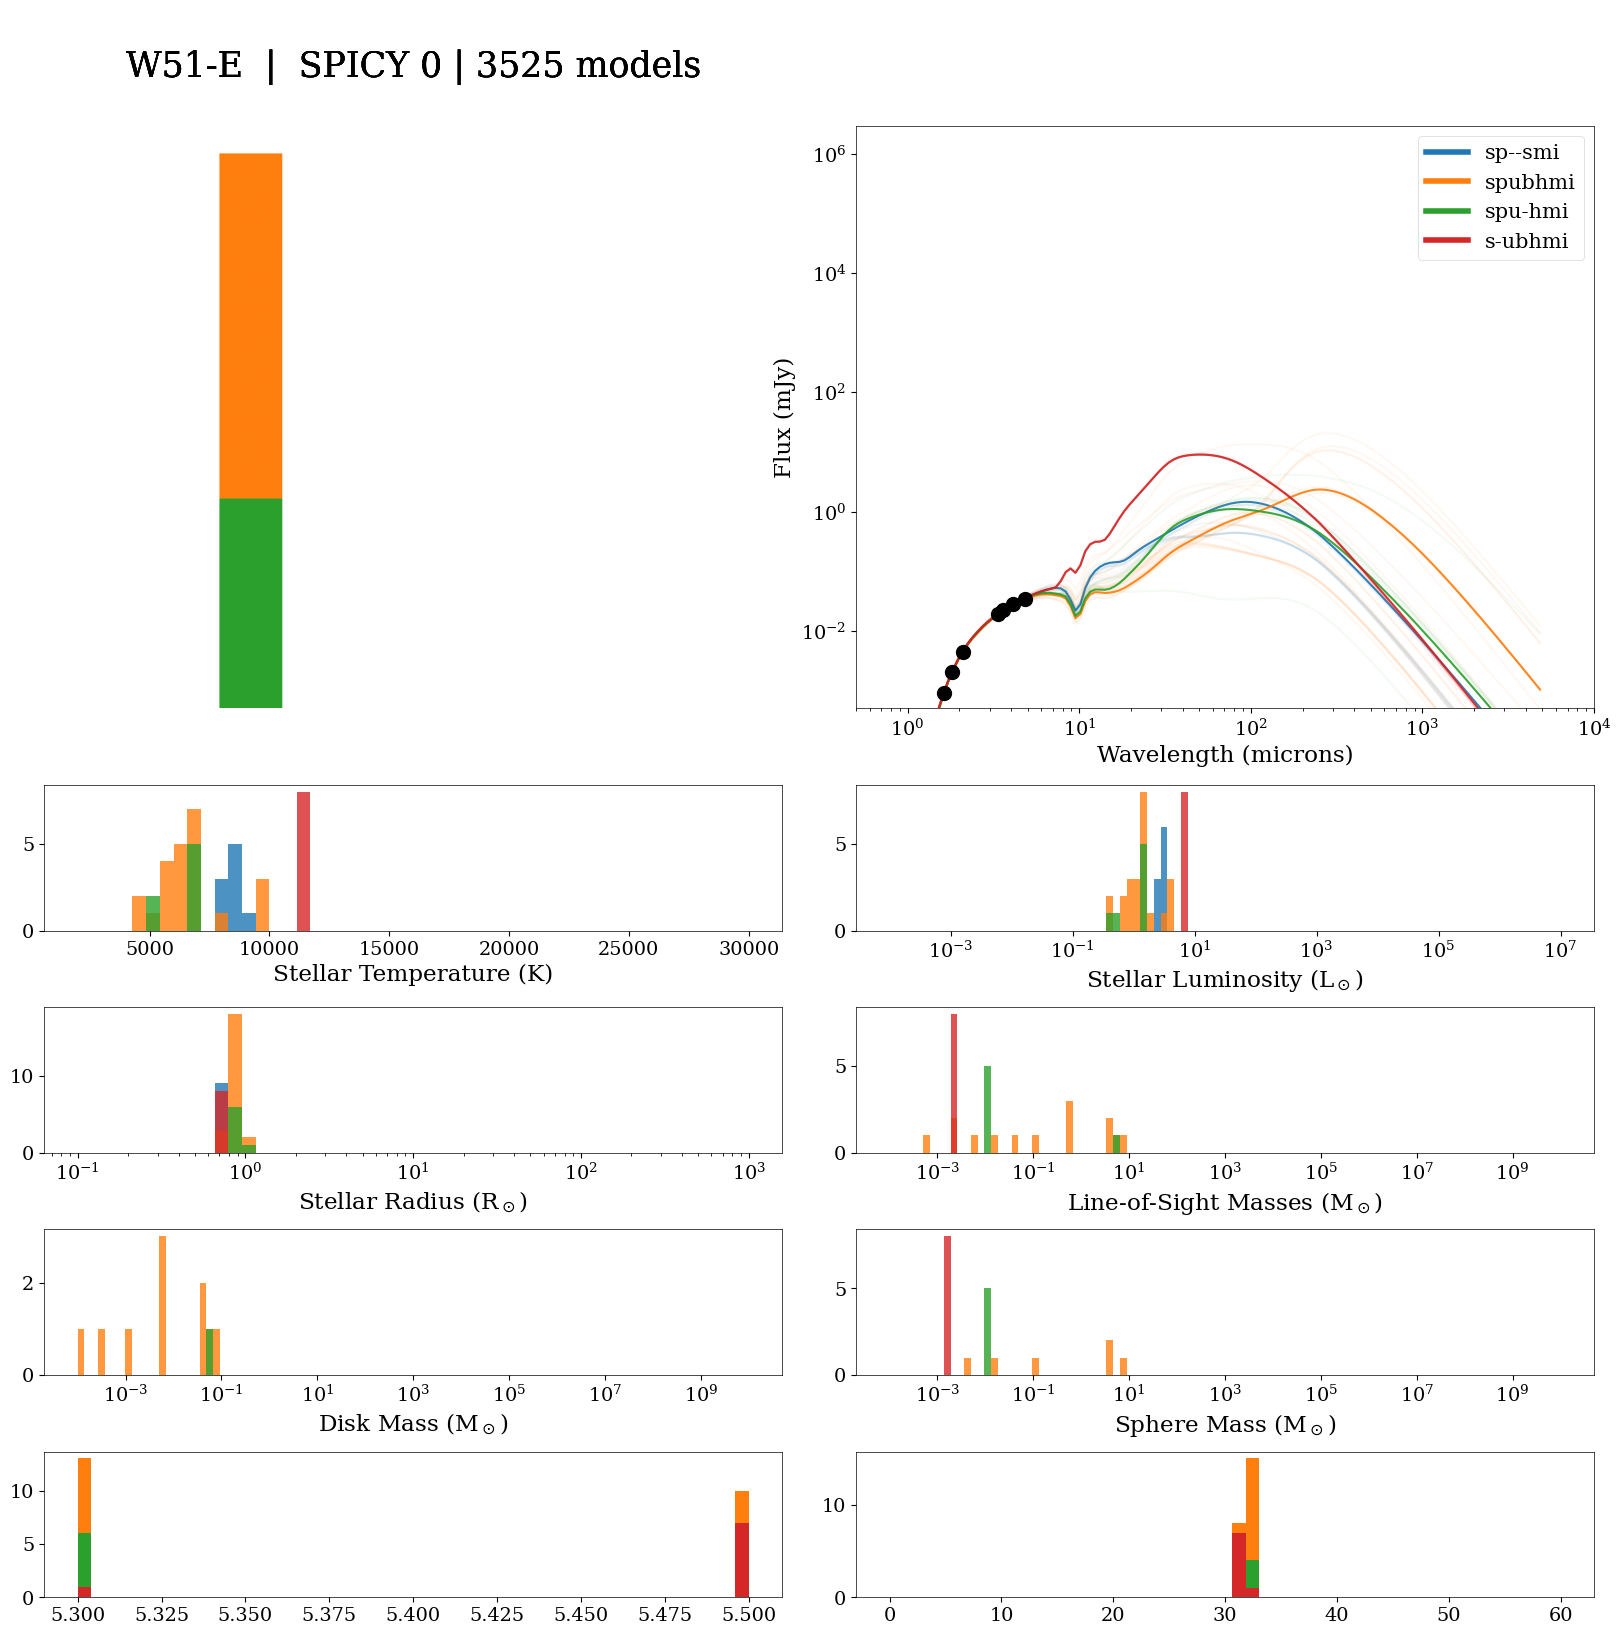

filt: f140m, flux_fit: 73.17852170857803, flux_err: 1.0322591313235925
filt: f162m, flux_fit: 311.0449780059631, flux_err: 3.831300673828703
filt: f182m, flux_fit: 497.037584786207, flux_err: 5.13636203698129
filt: f210m, flux_fit: 851.3496305973352, flux_err: 7.558545568835751
filt: f335m, flux_fit: 347.3511043849019, flux_err: 4.753140659535986
filt: f360m, flux_fit: 450.3841528216744, flux_err: 4.3645308958605495
filt: f410m, flux_fit: 505.0136810991928, flux_err: 5.709022631343563
filt: f480m, flux_fit: 502.43646425601673, flux_err: 8.10800866799388
filt: f560w, flux_fit: --, flux_err: --
filt: f770w, flux_fit: --, flux_err: --
filt: f1000w, flux_fit: --, flux_err: --
filt: f1280w, flux_fit: --, flux_err: --
filt: f2100w, flux_fit: --, flux_err: --
wcss[filt].proj_plane_pixel_area(): 7.525093724479512e-11 deg2
catalog[idx][f"flux_err_{filt}"]: 1.0322591313235925
fluxarr [0.00167745 0.00713267 0.01139348 0.01951541 0.03231284 0.04189505
 0.04698314 0.04675197]
['b3_id', 'b6_id', 'b3

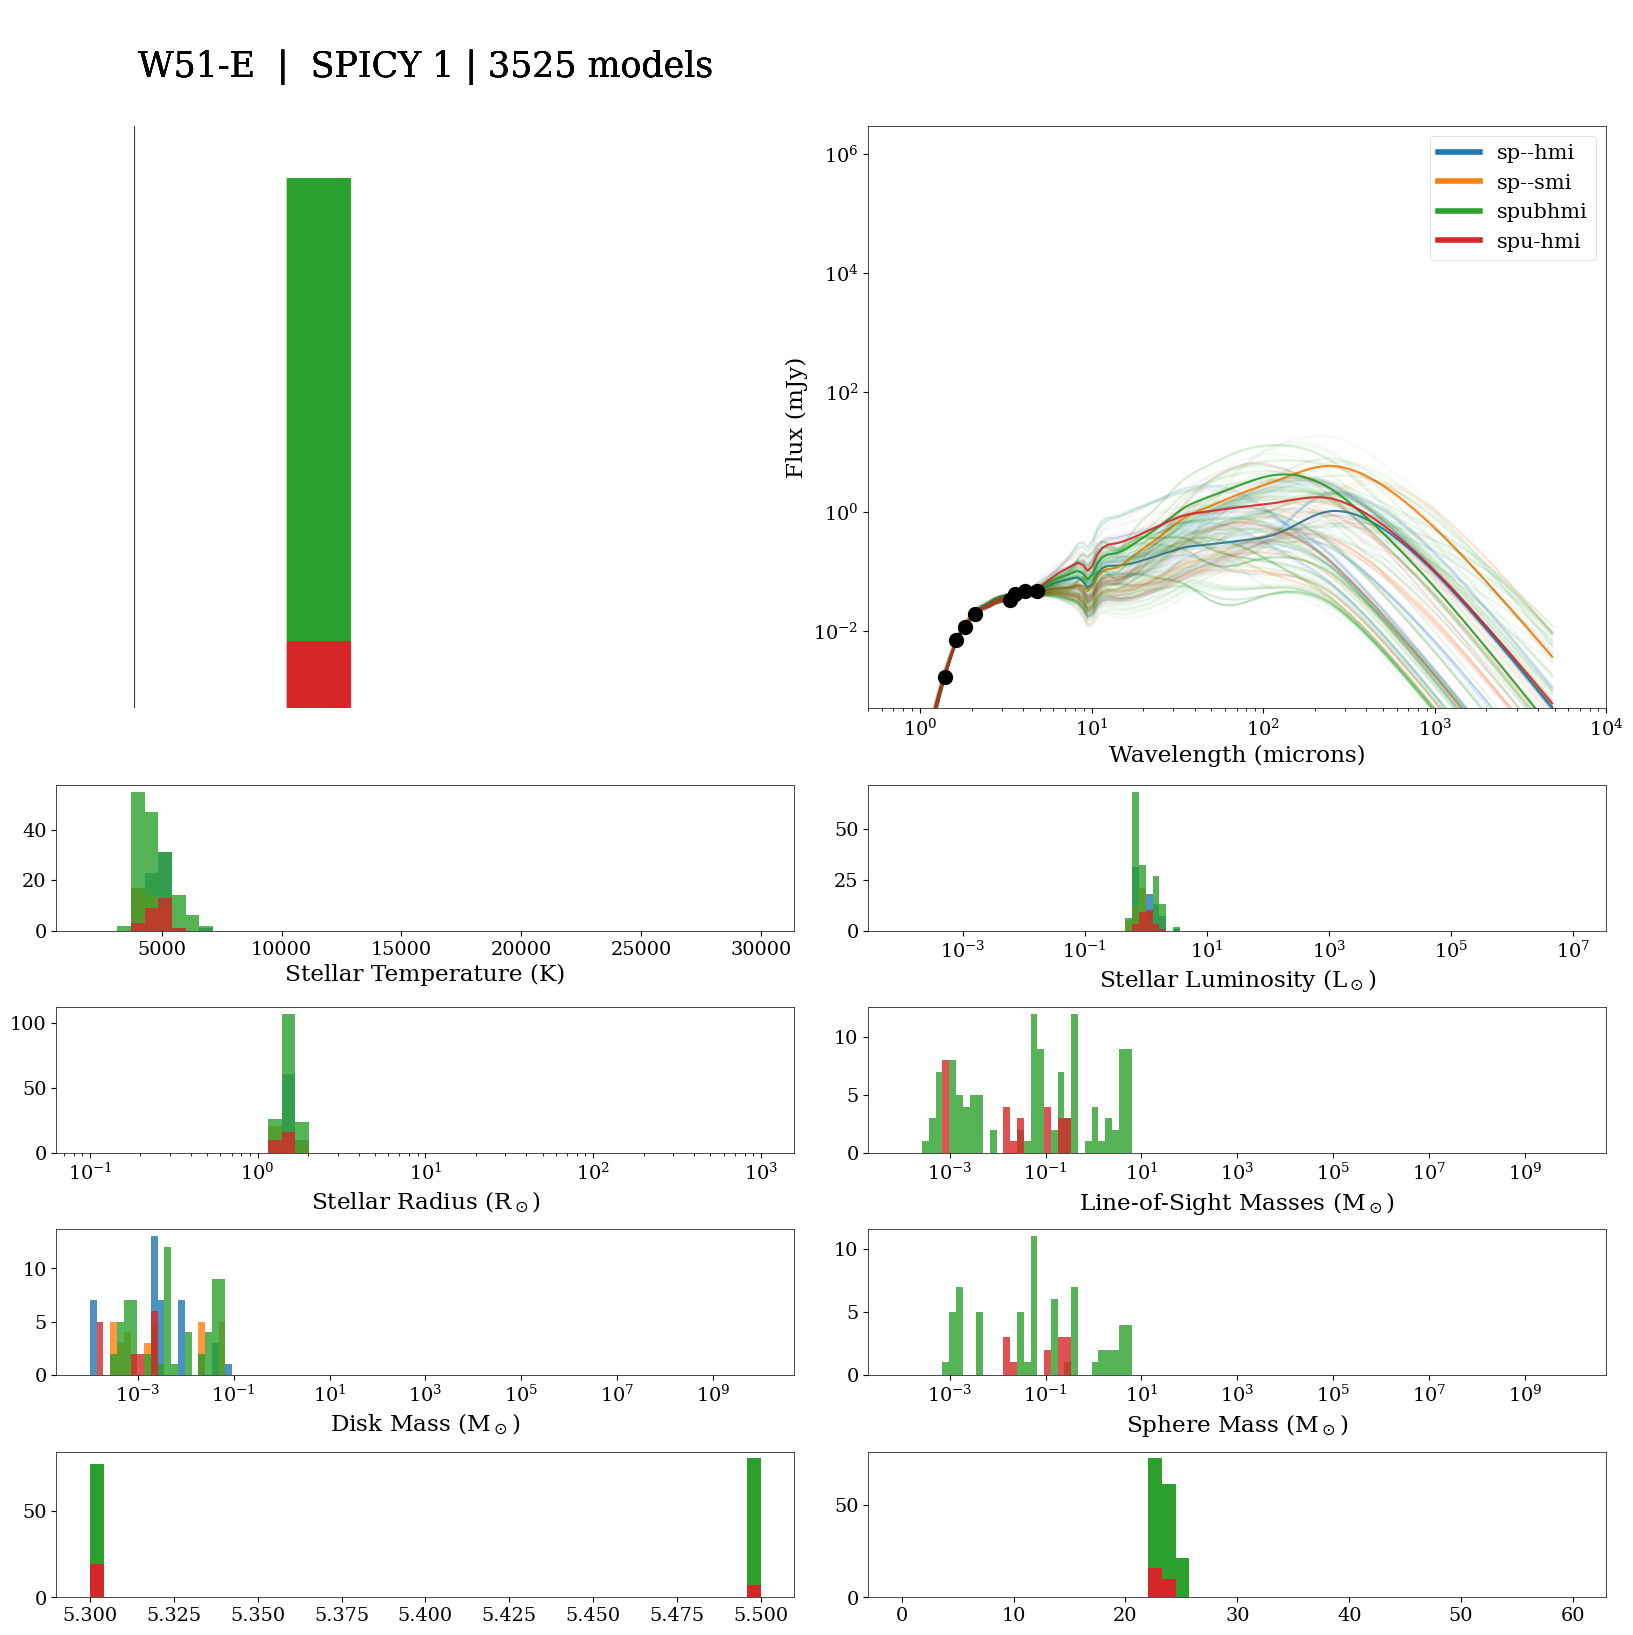

filt: f140m, flux_fit: 145.17045478996542, flux_err: 1.063322204289617
filt: f162m, flux_fit: 376.8220771705893, flux_err: 1.5044776697695548
filt: f182m, flux_fit: 520.4820559372108, flux_err: 1.5954467148885971
filt: f210m, flux_fit: 751.1788662696237, flux_err: 2.4078124096981766
filt: f335m, flux_fit: 272.30060827294193, flux_err: 6.348935615928372
filt: f360m, flux_fit: 294.7035327977205, flux_err: 3.0824805524710484
filt: f410m, flux_fit: 308.2781332566157, flux_err: 2.6129036535024857
filt: f480m, flux_fit: 313.9403011469581, flux_err: 2.7595321617818085
filt: f560w, flux_fit: --, flux_err: --
filt: f770w, flux_fit: --, flux_err: --
filt: f1000w, flux_fit: --, flux_err: --
filt: f1280w, flux_fit: --, flux_err: --
filt: f2100w, flux_fit: --, flux_err: --
wcss[filt].proj_plane_pixel_area(): 7.525093724479512e-11 deg2
catalog[idx][f"flux_err_{filt}"]: 1.063322204289617
fluxarr [0.00332771 0.00864103 0.0119309  0.0172192  0.02533116 0.02741353
 0.02868016 0.02921231]
['b3_id', 'b6_i

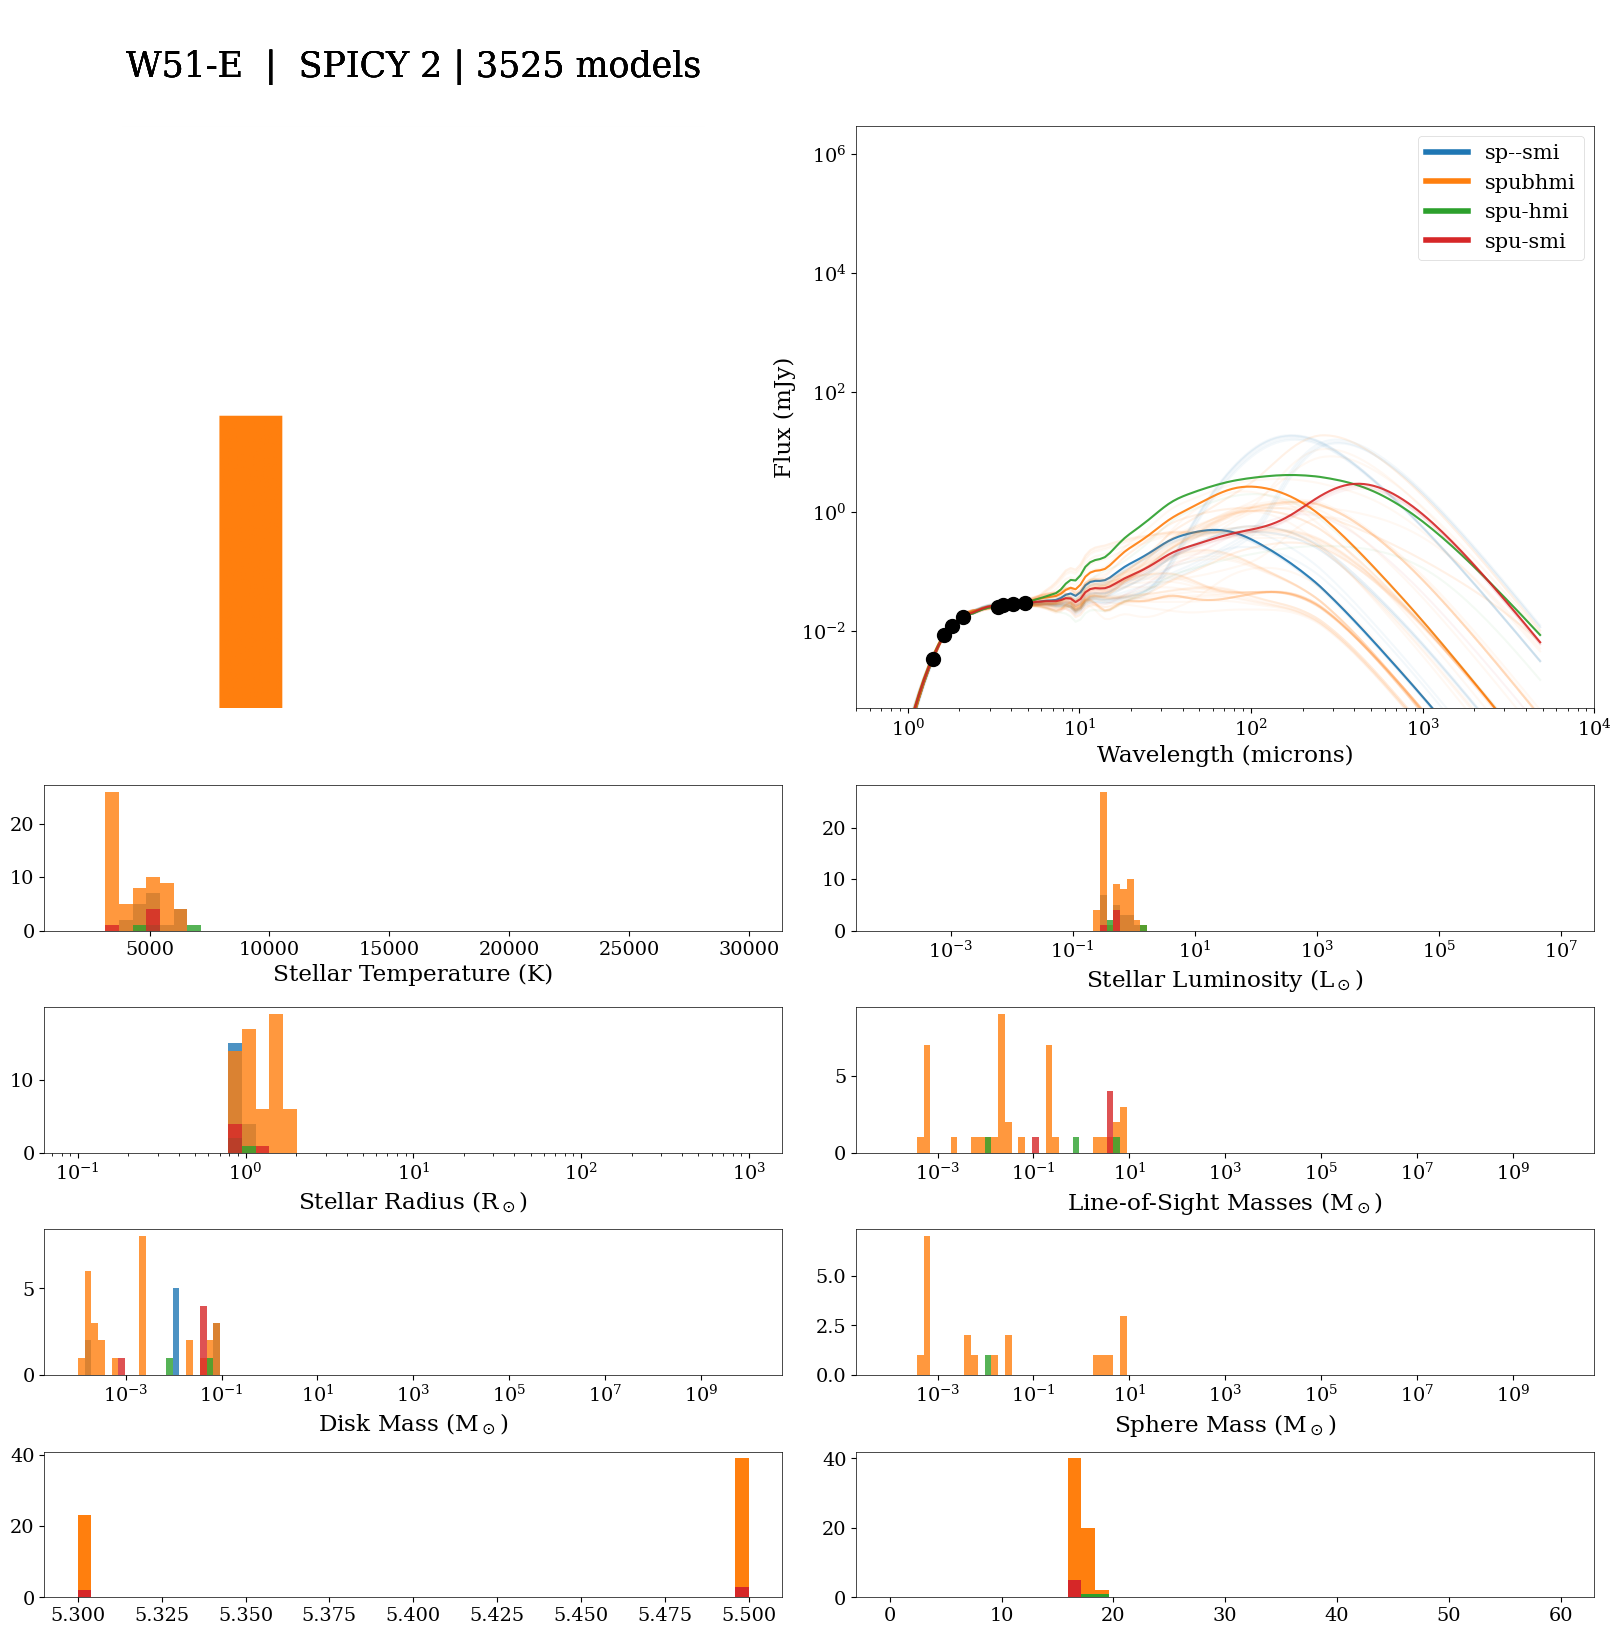

filt: f140m, flux_fit: 334.17879986348294, flux_err: 1.9333491525233635
filt: f162m, flux_fit: 984.0700723879953, flux_err: 3.740145397451986
filt: f182m, flux_fit: 1600.186983047222, flux_err: 4.897613057897708
filt: f210m, flux_fit: 2391.8153577253242, flux_err: 6.004312163324234
filt: f335m, flux_fit: 973.4547395087294, flux_err: 6.828826116761871
filt: f360m, flux_fit: 1080.9323991934987, flux_err: 6.369174293585112
filt: f410m, flux_fit: 1130.506497430465, flux_err: 6.02760277660014
filt: f480m, flux_fit: 1139.370351147929, flux_err: 5.558986310127133
filt: f560w, flux_fit: --, flux_err: --
filt: f770w, flux_fit: --, flux_err: --
filt: f1000w, flux_fit: --, flux_err: --
filt: f1280w, flux_fit: --, flux_err: --
filt: f2100w, flux_fit: --, flux_err: --
wcss[filt].proj_plane_pixel_area(): 7.525093724479512e-11 deg2
catalog[idx][f"flux_err_{filt}"]: 1.9333491525233635
fluxarr [0.0076603  0.02256603 0.03668073 0.05482737 0.09055703 0.1005491
 0.10517486 0.106019  ]
['b3_id', 'b6_id', '

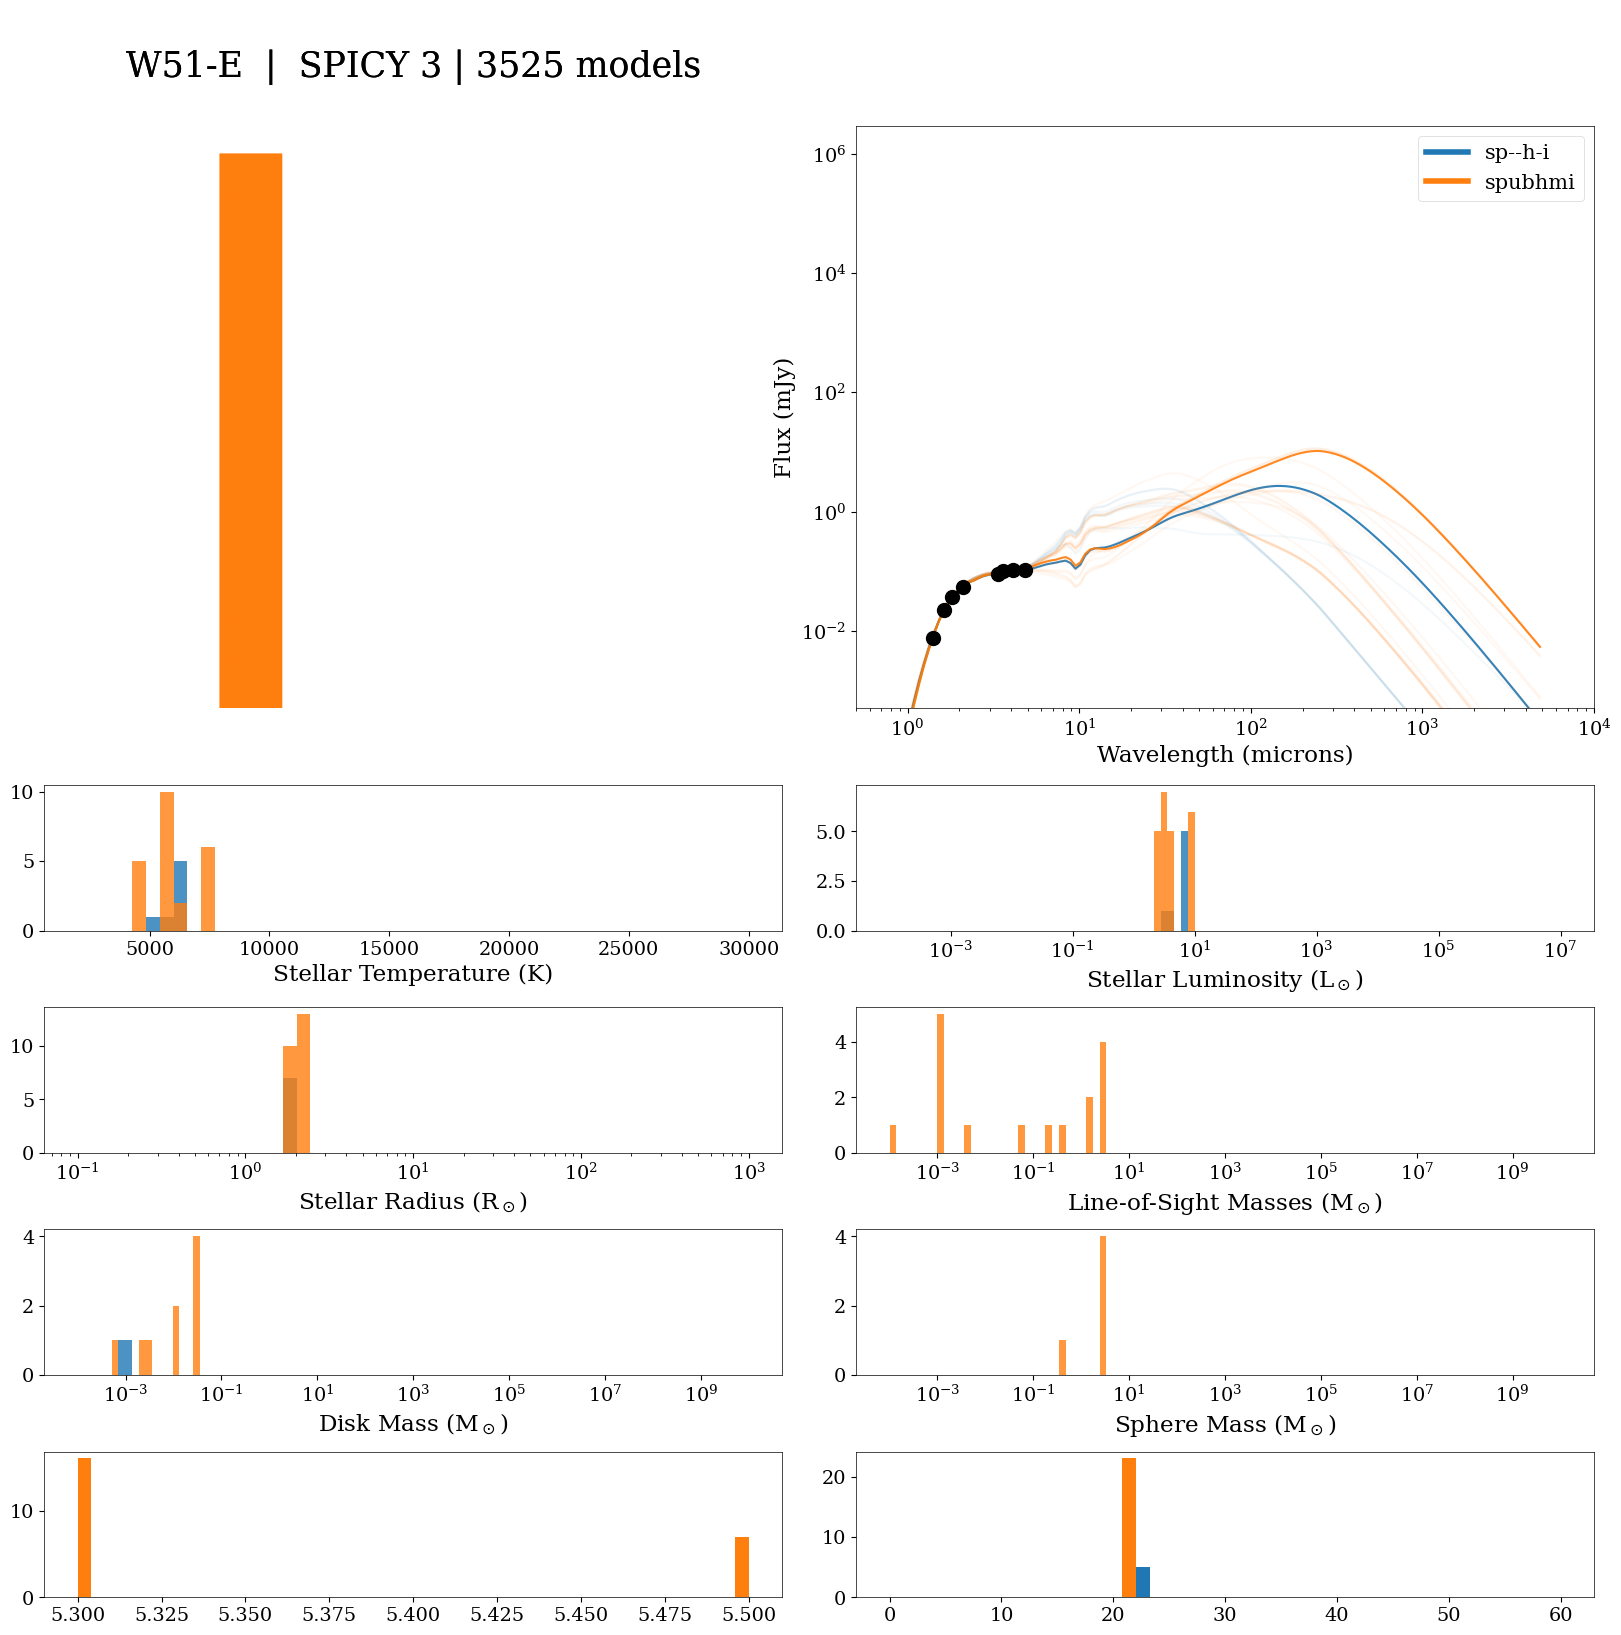

In [ ]:


from sedfitter.extinction import Extinction
from dust_extinction.shapes import P92

def make_extinction():
    ext = P92()

    guyver2009_avtocol = (2.21e21 * u.cm**-2 * (1.34 * u.Da)).to(u.g / u.cm**2)
    ext_wav = np.sort((np.geomspace(0.001, 1000, 10000) / u.um).to(u.um, u.spectral()))
    ext_vals = ext(ext_wav)

    extinction = Extinction()
    extinction.wav = ext_wav
    extinction.chi = ext_vals / guyver2009_avtocol
    return extinction

extinction = make_extinction()


imgs ={filt: fits.getdata(image_filenames[filt], ext=('SCI', 1)) for filt in image_filenames.keys()} 
wcss = {filt: WCS(fits.getheader(image_filenames[filt], ext=('SCI', 1))) for filt in image_filenames.keys()}
max_fluxs = {filt: np.nanmax(catalog[f'flux_fit_{filt}']) for filt in image_filenames.keys()}
filter_names = list(mags.keys())


line_slope = (27 - 7) / (1.3 - 0.4)
line_intercept = 7 - line_slope * 0.4


upper_idx = np.where((f360-f480 > 0.15 + (1.5/6)*(f162-f210)) & (f162 - (line_slope * (f162 - f210) + line_intercept) < 0))[0]
lower_idx = np.where((f360-f480 <= 0.15 + (1.5/6)*(f162-f210)) & (f162 - (line_slope * (f162 - f210) + line_intercept) < 0))[0]


def get_valid(catalog_row, filters, imgs, wcss, max_fluxs, masks):
    """
    flag whether the flux measurement is upper limit or lower limit
    """

    valid = np.ones(len(filters))
    # if flux in F560W, F770W, F1000W, F1280W, F2100W is NaN, then set valid to 0
    fluxarr = []
    for ii, filt in enumerate(filters):
        flux = (catalog_row[f'flux_fit_{filt}'] * u.MJy /u.sr* wcss[filt].proj_plane_pixel_area()).to(u.mJy).value
        if not np.isfinite(flux):
            skycoord = catalog_row[f'skycoord_{filt}']
            pixcoord = wcss[filt].world_to_pixel(skycoord)
            central_pix = imgs[filt][int(pixcoord[1]), int(pixcoord[0])]
            #check whether the cutout has nan pixels 
            issaturated = np.isnan(central_pix)
            if issaturated:
                valid[ii] = 3 #upper limit
                flux = max_fluxs[filt] * 1e3 
                if np.isnan(flux):
                    raise ValueError(f"Flux is NaN for filter {filt} at source {catalog_row['source_id']}")
            else:
                valid[ii] = 2
                aperture = SkyCircularAperture(skycoord, r=fwhms[ii]*u.arcsec)
                #arcsec^2 -> # of pixels
                # mask fwhm area of sources from catalog
            
                aperture_area = (fwhms[ii]*u.arcsec * fwhms[ii]*u.arcsec / wcss[filt].proj_plane_pixel_area()).to_value(u.dimensionless_unscaled)
                annulus = SkyCircularAnnulus(skycoord, r_in=fwhms[ii]*1.5*u.arcsec, r_out=fwhms[ii]*2*u.arcsec)
                annulus_stats = ApertureStats(imgs[filt], annulus, wcs=wcss[filt], mask =masks[filt])
                print('annulus_stats.mean, annulus_stats.median', annulus_stats.mean, annulus_stats.median,)
                bkg_mean = annulus_stats.mean
                phot_table = aperture_photometry(imgs[filt], aperture, wcs=wcss[filt])
                
                flux = (((phot_table['aperture_sum'][0] - bkg_mean * aperture_area))
                * u.MJy /u.sr* wcss[filt].proj_plane_pixel_area()).to(u.mJy).value
               

                if np.isnan(flux):
                    valid[ii]=3
                    flux = max_fluxs[filt] * 1e3 # Jy->mJy
            
        fluxarr.append(flux)
                
    return valid, np.array(fluxarr)



def add_alma(skycoord):
    from radio_beam import Beam
    from photutils.aperture import SkyEllipticalAperture
    from photutils.aperture import aperture_photometry
    w51e_b3_file = '/orange/adamginsburg/w51/TaehwaYoo/2017.1.00293.S_W51_B3_LB/may2021_successful_imaging/w51e2.spw0thru19.14500.robust0.thr0.075mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits'
    w51n_b3_file = '/orange/adamginsburg/w51/TaehwaYoo/2017.1.00293.S_W51_B3_LB/may2021_successful_imaging/w51n.spw0thru19.14500.robust0.thr0.075mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits'
    w51n_b6_file = '/orange/adamginsburg/w51/TaehwaYoo/w51n_b6_imaging_2025/w51n.spw0thru19.14500.robust0.thr0.1mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits'
    w51e_b6_file = '/orange/adamginsburg/w51/TaehwaYoo/w51e_b6_imaging_2025/w51e2.spw0thru19.14500.robust0.thr0.1mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits'

    w51e_alma_cat_file = '/orange/adamginsburg/w51/TaehwaYoo/dendro_w51e_master.fits'
    w51n_alma_cat_file = '/orange/adamginsburg/w51/TaehwaYoo/dendro_w51n_master.fits'
    w51e_b3_fits = fits.open(w51e_b3_file)
    w51n_b3_fits = fits.open(w51n_b3_file)
    w51n_b6_fits = fits.open(w51n_b6_file)
    w51e_b6_fits = fits.open(w51e_b6_file)

    w51e_b3_wcs = WCS(w51e_b3_fits[0].header)
    w51n_b3_wcs = WCS(w51n_b3_fits[0].header)
    w51n_b6_wcs = WCS(w51n_b6_fits[0].header)
    w51e_b6_wcs = WCS(w51e_b6_fits[0].header)
    
    w51e_b3_img = w51e_b3_fits[0].data[0][0]
    w51n_b3_img = w51n_b3_fits[0].data[0][0]
    w51n_b6_img = w51n_b6_fits[0].data[0][0]
    w51e_b6_img = w51e_b6_fits[0].data[0][0]

    w51e_alma_cat = Table.read(w51e_alma_cat_file)
    w51n_alma_cat = Table.read(w51n_alma_cat_file)

    # check whether skycoord is in the fov of the image
    fluxes = []
    flux_errs = []
    valids = []
    for alma_cat, b3_wcs, b6_wcs, b3_img, b6_img in zip([w51e_alma_cat, w51n_alma_cat], [w51e_b3_wcs, w51n_b3_wcs], [w51e_b6_wcs, w51n_b6_wcs], [w51e_b3_img, w51n_b3_img], [w51e_b6_img, w51n_b6_img]):
        print(alma_cat.colnames)
        for band in ['b6', 'b3']:
            skycoord_from_almacat = SkyCoord(ra=alma_cat[f'{band}_xsky']*u.deg, dec=alma_cat[f'{band}_ysky']*u.deg)
            separation = skycoord.separation(skycoord_from_almacat)
            ismatched = np.min(separation) < 0.1*u.arcsec


            if ismatched:
                flux = alma_cat[f'flux_{band}'][np.argmin(separation)].to(u.mJy).value
                fluxerr = alma_cat[f'fluxerr_{band}'][np.argmin(separation)].to(u.mJy).value
                print(f'matched with ALMA with flux: in {band} ', flux)

                valid = 1

            else:
                
                if band == 'b6':
                    wcs_alma = b6_wcs
                    img_alma = b6_img
                else:
                    wcs_alma = b3_wcs
                    img_alma = b3_img

                cel_wcs = wcs_alma.celestial
                pixcoord_alma = cel_wcs.world_to_pixel(skycoord)

                if (
                    pixcoord_alma[0] > 0 and pixcoord_alma[1] > 0
                    and pixcoord_alma[0] < img_alma.shape[1]
                    and pixcoord_alma[1] < img_alma.shape[0]
                ):

                    beam_alma = Beam.from_fits_header(wcs_alma.to_header())
                    aperture = SkyEllipticalAperture(
                        positions=skycoord,
                        a=beam_alma.major,
                        b=beam_alma.minor,
                        theta=beam_alma.pa,
                    )
                    phot_table = aperture_photometry(img_alma, aperture, wcs=wcs_alma)
                    flux = phot_table['aperture_sum'] * 1e3
                    fluxerr= phot_table['aperture_sum_err']  * 1e3
                    valid = 2
                    print(f'inside fov of {band}, flux: {flux}')
                else:
                    flux = np.nan
                    fluxerr = np.nan
                    valid = 0
                    print(f'outside fov of {band}')
                    print('pixcoord_alma:', pixcoord_alma, 'img_alma.shape:', img_alma.shape)                
              
        
            fluxes.append(flux)
            flux_errs.append(fluxerr)
            valids.append(valid)
    b6_flux = [fluxes[0], fluxes[2]]
    b3_flux = [fluxes[1], fluxes[3]]   
    b3_valid = [valids[1], valids[3]]
    b6_valid = [valids[0], valids[2]]
    if np.all(np.isnan(b3_flux)):
        b3_flux_final = np.nan
        b3_fluxerr_final = np.nan
    else:
        b3_flux_final = np.nanmean(b3_flux)
        b3_fluxerr_final = np.sqrt(np.nansum(np.array([flux_errs[1], flux_errs[3]])**2)) / len([flux_errs[1], flux_errs[3]])
    if np.all(np.isnan(b6_flux)):
        b6_flux_final = np.nan
        b6_fluxerr_final = np.nan
    else:
        b6_flux_final = np.nanmean(b6_flux)
        b6_fluxerr_final = np.sqrt(np.nansum(np.array([flux_errs[0], flux_errs[2]])**2)) / len([flux_errs[0], flux_errs[2]])
    return b3_flux_final, b3_fluxerr_final, b6_flux_final, b6_fluxerr_final, b3_valid, b6_valid


    


        



# get the wavelengths and fwhm for each filter
fwhms = []
fwhms_pix = []
wavelengths = []
for ii, filt in enumerate(filter_names):
    header = fits.getheader(image_filenames[filt], ext=('SCI', 1))
    if filt in ['f140m', 'f162m', 'f182m', 'f187n', 'f210m', 'f335m', 'f360m', 'f405n', 'f410m', 'f480m']:
        instrument_replacement = 'NIRCam'
    elif filt in ['f560w', 'f770w', 'f1000w', 'f1280w', 'f2100w']:
        instrument_replacement = 'MIRI'
    fwhm_tbl = Table.read('/orange/adamginsburg/w51/jwst/reduction/fwhm_table.ecsv')
    row = fwhm_tbl[fwhm_tbl['Filter'] == filt.upper()]
    fwhm = fwhm_arcsec = float(row['PSF FWHM (arcsec)'][0])
    pixel_scale = wcss[filt].proj_plane_pixel_scales()[0]
    fwhm_pix = fwhm_arcsec / pixel_scale.to_value(u.arcsec)
    #fwhm, fwhm_pix = get_fwhm(header, instrument_replacement=instrument_replacement)
    fwhms.append(fwhm_arcsec)
    fwhms_pix.append(fwhm_pix)
    wav = int(filt[1:-1])/100 #um
    wavelengths.append(wav)
fwhms = np.array(fwhms)
wavelengths = np.array(wavelengths)


# create masks for each filter based on the catalog sources (this is for aperture photometry)
masks = {}
for ii, filt in enumerate(filter_names):
    mask = np.isnan(imgs[filt])
    skycoord = catalog[f'skycoord_{filt}']
    pixcoord = wcss[filt].world_to_pixel(skycoord)

    mask[pixcoord[1].astype(int), pixcoord[0].astype(int)] = True
    R = int(np.ceil(fwhms_pix[ii]/2))
    yy, xx = np.ogrid[-R:R+1, -R:R+1]
    footprint = xx**2 + yy**2 <= R**2
    mask = binary_dilation(mask, structure=footprint)

    masks[filt] = mask


stellar_lum_upper = []
stellar_lum_lower = []
stellar_temp_upper = []
stellar_temp_lower = []


for ii, idx in enumerate(upper_idx):
    if ii<=3:
        for filt in filter_names:
            print(f'filt: {filt}, flux_fit: {catalog[idx][f"flux_fit_{filt}"]}, flux_err: {catalog[idx][f"flux_err_{filt}"]}')
        #fluxarr = np.array([catalog[idx][f'flux_fit_{filt}'] for filt in filter_names])
        skycoord = catalog[idx]['skycoord_ref']
        pixcoord_f560w = wcss['f560w'].world_to_pixel(skycoord)
        if pixcoord_f560w[0] < 0 or pixcoord_f560w[1] < 0 or pixcoord_f560w[0] >= imgs['f560w'].shape[1] or pixcoord_f560w[1] >= imgs['f560w'].shape[0]:
            filternames_use = ['f140m', 'f162m', 'f182m', 'f210m', 'f335m', 'f360m', 'f410m', 'f480m']
            imgs_use = {filt: imgs[filt] for filt in filternames_use}
            wcss_use = {filt: wcss[filt] for filt in filternames_use}
            max_fluxs_use = {filt: max_fluxs[filt] for filt in filternames_use}
            masks_use = {filt: masks[filt] for filt in filternames_use}
            wavelengths_use = [wavelengths[filter_names.index(filt)] for filt in filternames_use]
            fwhms_use = [fwhms[filter_names.index(filt)] for filt in filternames_use]
        else:
            filternames_use = filter_names
            imgs_use = imgs
            wcss_use = wcss
            max_fluxs_use = max_fluxs
            masks_use = masks
            wavelengths_use = wavelengths
            fwhms_use = fwhms
        

        # check the unit of flux_err in the catalog, it is in MJy/sr, so we need to convert it to mJy
        print('wcss[filt].proj_plane_pixel_area():', wcss['f140m'].proj_plane_pixel_area())
        print('catalog[idx][f"flux_err_{filt}"]:', catalog[idx][f'flux_err_f140m'])
        fluxerr = u.Quantity([(catalog[idx][f'flux_err_{filt}'] * u.MJy / u.sr * wcss[filt].proj_plane_pixel_area().to(u.sr)).to(u.mJy) for filt in filternames_use]) # Jy -> mJy
        

        valid, fluxarr = get_valid(catalog[idx], filternames_use, imgs_use, wcss_use, max_fluxs_use, masks_use)


        

        print('fluxarr', fluxarr)
        tab_upper = Table()
        tab_upper['aperture'] = fwhms_use
        tab_upper['wavelength'] = wavelengths_use
        tab_upper['flux'] = fluxarr
        tab_upper['eflux'] = fluxerr
        tab_upper['aperture'].unit = u.arcsec
        tab_upper['wavelength'].unit = u.um
        tab_upper['flux'].unit = u.mJy
        tab_upper['eflux'].unit = u.mJy


        b3_flux, b3_fluxerr, b6_flux, b6_fluxerr, b3_valid, b6_valid = add_alma(catalog[idx]['skycoord_ref'])
        print('b3_flux, b3_fluxerr, b6_flux, b6_fluxerr:', b3_flux, b3_fluxerr, b6_flux, b6_fluxerr)
        print('b3_valid', b3_valid)
        print('b6_valid', b6_valid)
        if not np.isnan(b6_flux):
            tab_upper.add_row([fwhms[-1], 1300, b6_flux, b6_fluxerr])
            valid.append(b6_valid)
        if not np.isnan(b3_flux):
            tab_upper.add_row([fwhms[-1], 3000, b3_flux, b3_fluxerr])   
            valid.append(b3_valid)
        print('flux', tab_upper['flux'])
        print('wavelength', tab_upper['wavelength'])
        print('valid', valid)
        print('av_estimates[idx]:', av_estimates[idx])
        fits_dict = {geom:
            fit_a_source(data=tab_upper['flux'].quantity,
                error=tab_upper['eflux'].quantity,
                valid=valid, aperture_size=tab_upper['aperture'].quantity,
                filters=tab_upper['wavelength'].quantity,
                    av_range=[av_estimates[idx], 100],
                    distance_range=[5300,5500]*u.pc,
                        geometry=geom,
                        stash_to_mmap=True,
                        robitaille_modeldir='/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2',
                        extinction=extinction
                    )
            for geom in geometries}#['spubhmi']} #geometries}
        okgeo = []
        for geom in geometries:
            minchi2 = min([np.nanmin(fits_dict[geom].chi2) for geom in fits_dict])
            
            chi2limit = minchi2*3 if minchi2 > 3 else 9
            deltachi2limit = chi2limit - minchi2
            print(f"Delta-chi^2 = {deltachi2limit} for min chi2 = {minchi2}")
            if np.nanmin(fits_dict[geom].chi2) < deltachi2limit+minchi2:
                okgeo.append(geom)
        print('okgeo:', okgeo)
        if len(okgeo)>0:
            
                #plot_fit(fits, geom, chi2limit=chi2limit, min_chi2=minchi2);
            #for geom in okgeo:
            plot_fit(fits=fits_dict, okgeo=okgeo, fieldid='W51-E', spicyid=ii, 
            chi2limit=minchi2*3, min_chi2=minchi2, show_all_models=True, extinction=extinction,
            loc_imagedir='/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/seds_spicy', robitaille_modeldir='/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2',)
            
            # append fit params for each source

    
    
#cb26tbl = Table(rows=data,
#                names=['wavelength', 'flux', 'eflux', 'aperture'],
#                units=(u.um, u.mJy, u.mJy, u.arcsec)
#               )

In [15]:
dd

NameError: name 'dd' is not defined

In [ ]:
import plot_SED

for ii, idx in enumerate(upper_idx):
    if ii<=3:
        skycoord = catalog[idx]['skycoord_ref']
        plot_SED.plot_SED(skycoord, ii, SEDsavedir=None, show=True)
